# Load & Explore Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [4]:
df = pd.read_csv("output.csv")

# Fix column name (remove space)
df.rename(columns={' Review':'Review'}, inplace=True)

df.head(10)

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
5,Now I am getting angry and I want my damn pho.,0
6,Honeslty it didn't taste THAT fresh.),0
7,The potatoes were like rubber and you could te...,0
8,The fries were great too.,1
9,A great touch.,1


# Basic Exploration

## check class distribution

In [5]:
print(df['Liked'].value_counts())

Liked
1    500
0    500
Name: count, dtype: int64


## check missing values

In [6]:
print(df.isnull().sum())

Review    0
Liked     0
dtype: int64


## review length distribution

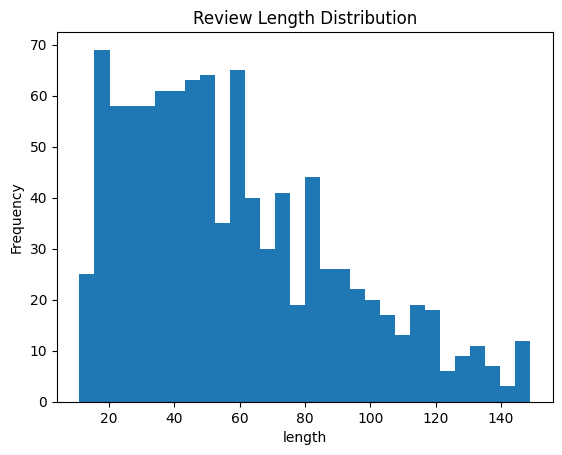

In [7]:
df['length'] = df['Review'].apply(len)

plt.hist(df['length'], bins=30)
plt.title("Review Length Distribution")
plt.xlabel("length")
plt.ylabel("Frequency")
plt.show()

## Text cleaning

In [8]:
# download nltk resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\Amrutha
[nltk_data]     Reddy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Amrutha
[nltk_data]     Reddy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## cleaning function

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # 1.lowercase
    text = text.lower()

    #2. remove punctuation & numbers
    text = re.sub(r'[^a-z\s]','',text)

    #3.remove extra spaces 
    text = re.sub(r'\s+','',text).strip()

    #4.remove stopwords + lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word)for word in words if word not in stop_words]

    return"".join(words)

## cleaning

In [11]:
df['clean_review'] = df['Review'].apply(clean_text)
df[['Review','clean_review']].head()

,Review,clean_review
0,Wow... Loved this place.,wowlovedthisplace
1,Crust is not good.,crustisnotgood
2,Not tasty and the texture was just nasty.,nottastyandthetexturewasjustnasty
3,Stopped by during the late May bank holiday of...,stoppedbyduringthelatemaybankholidayoffrickste...
4,The selection on the menu was great and so wer...,theselectiononthemenuwasgreatandsoweretheprices


## convert text to Features(TF-IDF)

In [15]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_review'])
y = df['Liked']

## Train-Test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

## Train Bernoulli Naive Bayes

In [17]:
model = BernoulliNB()
model.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


## Evaluate Model

In [18]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precisions:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test,y_pred))

Accuracy: 0.48
Precisions: 0.0
Recall: 0.0
F1 Score: 0.0


C:\Users\Amrutha Reddy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## classification Report

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      1.00      0.65        96
           1       0.00      0.00      0.00       104

    accuracy                           0.48       200
   macro avg       0.24      0.50      0.32       200
weighted avg       0.23      0.48      0.31       200



C:\Users\Amrutha Reddy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Amrutha Reddy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Amrutha Reddy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

## confusion matrix

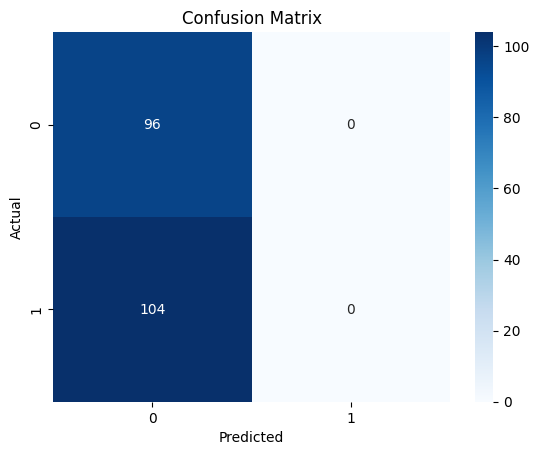

In [21]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot = True, fmt='d', cmap = 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## predict New Reviews

In [29]:
from sklearn.naive_bayes import MultinomialNB

In [30]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [31]:
cleaned = [clean_text(r) for r in new_reviews]
vectorized = vectorizer.transform(cleaned)
predictions = model.predict(vectorized)

for review, pred in zip(new_reviews, predictions):
    
    if pred == 1:
        print(review, "-> Positive 🙂")
    else:
        print(review, "-> Negative 🙁")

The food was fantastic -> Negative 🙁
Worst service ever. -> Negative 🙁


In [32]:
print(df['Liked'].value_counts())

Liked
1    500
0    500
Name: count, dtype: int64


In [33]:
print("fantastic" in vectorizer.vocabulary_)
print("worst" in vectorizer.vocabulary_)
print("food" in vectorizer.vocabulary_)

False
False
False


In [34]:
for r in new_reviews:
    print(clean_text(r))

thefoodwasfantastic
worstserviceever


## save model deployment

In [40]:
pickle.dump(model, open("model.pkl","wb"))
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))